# Practical 1 — Numerical Optimization: General Review

Authors: Guillem Calvo and Oscar Romero

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

## 1. The one-dimensional case

$$\boxed{f_1(x) = x^3-2x+2}$$

We will start by plotting $f_1(x)$. 

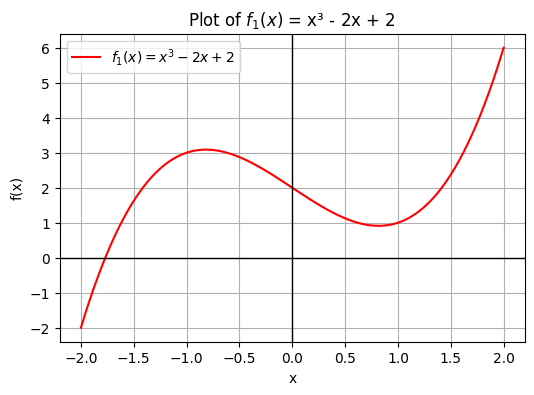

In [3]:
def f_1(x):
    return x**3 - 2*x + 2


x = np.linspace(-2, 2, 400)  
y = f_1(x)


plt.figure(figsize=(6, 4))
plt.plot(x, y, label=r"$f_1(x) = x^3 - 2x + 2$", color="red")
plt.axhline(0, color="black", linewidth=1)  
plt.axvline(0, color="black", linewidth=1)  
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Plot of $f_1(x)$ = x³ - 2x + 2")
plt.legend()
plt.grid(True)
plt.show()

The derivative of $f_1$ can be easily calculated: $$f_1'(x) = 3x^2 -2$$
$$f_1'(x) = 0 \Longleftrightarrow 3x^2=2 \Longleftrightarrow x=\pm \sqrt{\frac{2}{3}}$$.

Calculating the second derivative, we obtain the second-order Taylor expansion.
$$f_1''(x)= 6x$$
$$f(x^*+d) = f(x^*)+ df'(x^*)+\frac{1}{2}d^2f''(x^*) + O(d^3)$$
$$f_1(\sqrt{\frac{2}{3}}+d) = f_1(\sqrt{\frac{2}{3}}) + 3d^2\sqrt{\frac{2}{3}}+O(d^3)\Longrightarrow f_1(\sqrt{\frac{2}{3}}) \leq f_1(\sqrt{\frac{2}{3}}+d) +O(d^3)$$

$$f_1(-\sqrt{\frac{2}{3}}+d) = f_1(-\sqrt{\frac{2}{3}}) - 3d^2\sqrt{\frac{2}{3}}+O(d^3)\Longrightarrow f_1(-\sqrt{\frac{2}{3}}) \geq f_1(-\sqrt{\frac{2}{3}}+d) +O(d^3)$$

Hence, for a sufficiently small $d$, the inequality we are looking for holds. That is,

- $x^*_1 = \sqrt{\frac{2}{3}}$ is a local minimum.
- $x^*_2 = -\sqrt{\frac{2}{3}}$ is a local maximum.

More generally, the condition of local maximum/minimum is given by the sign of $f''(x)$. Indeed, assuming $f'(x^*) = 0$, then by the Taylor Theorem:

- If $f''(x^*)<0 \Longrightarrow f(x^*+d)<f(x^*+d) + \frac{d^2}{2}f''(x^*) = f(x^*) + O(d^3) \Longrightarrow f(x^*+d)<f(x^*)$ for $d\in B_\epsilon(0)$ and a sufficiently small $\epsilon>0$.

Similarly, with $f''(x^*)>0$, it yields a local minimum.

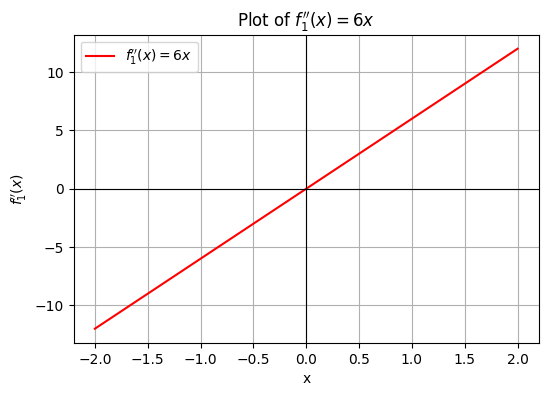

In [4]:
def g(x):
    return 6*x


x = np.linspace(-2, 2, 400)  
y = g(x)


plt.figure(figsize=(6, 4))
plt.plot(x, y, label=r"$f_1''(x) = 6x$", color="red")
plt.axhline(0, color="black", linewidth=0.8)  
plt.axvline(0, color="black", linewidth=0.8)  
plt.xlabel("x")
plt.ylabel(r"$f_1''(x)$")
plt.title(r"Plot of $f_1''(x) = 6x$")
plt.legend()
plt.grid(True)
plt.show()

In the image above, we can see how the second derivative changes its sign. Hence the positive critical point is a minimum and the negative one is a maximum. 

## 2. The two-dimensional case

### 2.1. A simple two-dimensional function

$$\boxed{f_2(\mathbf{x}) = x_1^2+x_2^2}$$

In [5]:
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-2, 2, 200)
X1, X2 = np.meshgrid(x1, x2)
F = X1**2 + X2**2

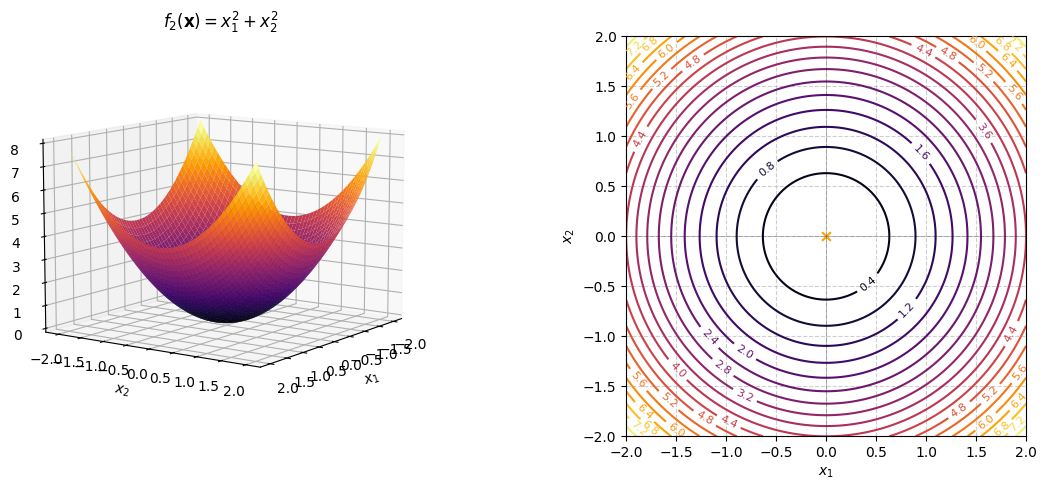

In [6]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1, X2, F, cmap='inferno', edgecolor='none')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f_2$')
ax1.set_title(r'$f_2(\mathbf{x}) = x_1^2 + x_2^2$')
ax1.view_init(elev=10, azim=35)

ax2 = fig.add_subplot(1, 2, 2)
contours = ax2.contour(X1, X2, F, levels=20, cmap='inferno')
ax2.clabel(contours, inline=True, fontsize=8)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.3)  #hline x2=0
ax2.axvline(0, color='k', linewidth=0.5, alpha=0.3)  #vine x1=0
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
# ax2.set_title(r'Contour plot of $f_2(x_1, x_2) = x_1^2 + x_2^2$')
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.scatter(0, 0, color='orange', marker='x', s=40) #(x_1, x_2)=(0,0)
ax2.set_aspect('equal', 'box')  

plt.tight_layout()
plt.show()


From the 3D plot, we can already discern that the function reaches its minimum at $(x_1, x_2)^T=(0,0)^T$, which is even more clearly illustrated in the contour plot. Nevertheless, we will proceed to compute the minimum of this two-variable function analytically.

Since the gradient of a function f is defined as $\nabla f = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)^T$ and for our function $\frac{\partial f}{\partial x_i} = 2x_i \ \Rightarrow \ \boxed{\nabla f_2(\mathbf{x}) = \left(2x_1, 2x_2\right)^T}$ 

Trivially we can compute that the point $\mathbf{x^*}$ at which $\nabla f_2(\mathbf{x}^*)=0$ is $\boxed{\mathbf{x}^*=(0,0)^T}$.

 The Taylor expansion (up to second order) of a function of several variables can be compactly expressed as

 $f(\mathbf{x}^*+\mathbf{d}) \approx f(\mathbf{x}^*)+ \mathbf{d}^T\nabla f(\mathbf{x}^*)+\tfrac{1}{2}\mathbf{d}^T\nabla^2 f(\mathbf{x}^*)\mathbf{d}$

This expression can be understood term by term, considering each of the terms that are summed up. The first term is just the value of the function $f$ at $\mathbf{x^*}$. The second term is the linear one, since it gives information about how the function changes along the direction $\mathbf{d}$ using the gradient. The third one is the quadratic term, and it accounts for the curvature of the function along $\mathbf{d}$ by using the Hessian matrix. The sum of this three terms gives a second order approximation of the value of $f(\mathbf{x}^*+\mathbf{d})$. Very similarly to the one-dimensional case. 

The bidimensional Hessian matrix is $\nabla^2 f(\mathbf{x}) =
\begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} \\[2mm]
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2}
\end{bmatrix}$.
Computing each entry for our function $f_2$ we get: $\frac{\partial^2 f_2}{\partial x_1^2}=\frac{\partial^2 f_2}{\partial x_2^2}=2$ and $\frac{\partial^2 f_2}{\partial x_1 \partial x_2}=\frac{\partial^2 f_2}{\partial x_2 \partial x_1}=0$. 

Therefore, the Hessian is constant:
$\nabla^2 f_2(\mathbf{x}) =
\begin{bmatrix}
2 & 0 \\[2mm]
0 & 2
\end{bmatrix}$.

Since the Hessian matrix provides information about the shape of the quadratic approximation at $\mathbf{x}=\mathbf{x^*}$ , we will study the eigenvalues of the matrix $H=\nabla^2 f(\mathbf{x})$ to determine the curvature of the function to know whether it is locally concave or convex. The eigenvalues $\lambda$ are obtained by solving the matrix equation $H-\lambda I=0$. In this case, the solution is straightforward, since the eigenvalues of a diagonal matrix are exactly the entries on its diagonal. Therefore, we have $\lambda_1=\lambda_2=2$.


Since the eigenvalues of $\nabla^2 f(\mathbf{x})$ are strictly positive, the following condition is satisfied: $\;\;\; \mathbf{d}^T\nabla^2 f(\mathbf{x}^*)\mathbf{d}>0 \;\;\; \mathbf{d} \neq 0$

This means that our function is locally convex and that we indeed have a minimum at $\mathbf{x} = \mathbf{x^*}$. We will prove similarly as we have proven the one-dimensional case. 


Proof.

By considering the second-order multivariate Taylor series around $x^*$ and applying the Mean Value Theorem, there exists a point
$\mathbf{c}\in<\mathbf{x^*}-\mathbf{d},\mathbf{x^*}+\mathbf{d}>$ such that:
$$ f(\mathbf{x}^*+\mathbf{d})- f(\mathbf{x}^*)- \mathbf{d}^T\nabla f(\mathbf{x}^*) = \tfrac{1}{2}\mathbf{d}\nabla^2 f(\mathbf{c})\mathbf{d} = \tfrac{\xi^2}{2}(\mathbf{x^*-c})\nabla^2 f(\mathbf{c})(\mathbf{x^*-c}) >0$$ since $\mathbf{x^*}-\mathbf{c} = \xi\mathbf{d}$ for some $\xi\in\mathbb{R}$.

Yielding:
$$ f(\mathbf{x}^*) < f(\mathbf{x}^*+\mathbf{d})-\mathbf{d}^T\nabla f(\mathbf{x}^*) = f(\mathbf{x}^*+\mathbf{d}) \Longrightarrow \mathbf{x^*} \ \text{local minima}$$

Similarly, it can be proven for the maximum case, where we seek $\;\;\; \mathbf{d}^T\nabla^2 f(\mathbf{x}^*)\mathbf{d}<0 \;\;\; \mathbf{d} \neq 0$.

If all the eigenvalues of $\nabla^2 f(\mathbf{x})$ are strictly positive or strictly negative, the Hessian informs us that the function is locally convex or concave, respectively. To investigate this further, what happens if some eigenvalues are positive and others negative, or even zero? To explore this, we will study the following functions:          
$\;\;\;\; \begin{aligned}
f_A(\mathbf{x}) &= -x_1^2 - x_2^2, & 
f_B(\mathbf{x}) &= x_1^2 - x_2^2, & 
f_C(\mathbf{x}) &= x_1^2
\end{aligned}$

We will start by studying $f_A(\mathbf{x})$. Let's plot the function with a 3D view and contour lines as we did before.

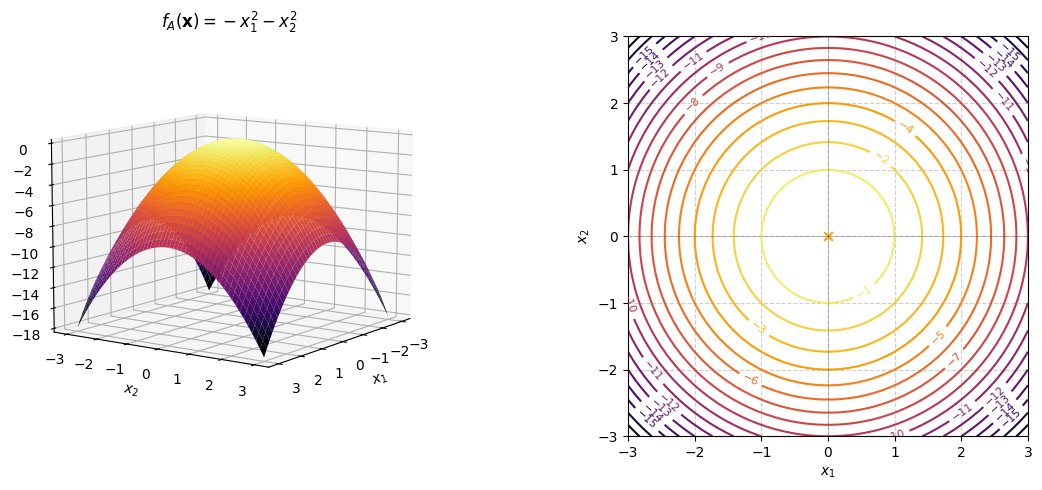

In [7]:
x1 = np.linspace(-3, 3, 50)
x2 = np.linspace(-3, 3, 50)
X1, X2 = np.meshgrid(x1, x2)
F_A = -X1**2 - X2**2

fig = plt.figure(figsize=(12,5))

# 3D plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1, X2, F_A, cmap='inferno', edgecolor='none')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f_A$')
ax1.set_title(r'$f_A(\mathbf{x})=-x_1^2-x_2^2$')
ax1.view_init(elev=10, azim=35)

# Contour plot
ax2 = fig.add_subplot(1, 2, 2)
contours = ax2.contour(X1, X2, F_A, levels=20, cmap='inferno')
ax2.clabel(contours, inline=True, fontsize=8)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.scatter(0, 0, color='orange', marker='x', s=40)
ax2.set_aspect('equal', 'box')  

plt.tight_layout()
plt.show()

We can already see from the plot that we have a case similar to the previous one, with a relative extremum at $(0,0)^T$, but in this case it is where the maximum value of $f(x)$ is found.

If we compute de gradient of $f_A$ and set it equal to zero, we get:

$\nabla f_A (\mathbf{x}) = \left(-2x_1, -2x_2\right)^T=\textbf{0} \ \ \textrm{when} \ \ \mathbf{x^*}=(0,0)^T.$

So, for now we have the same situation at the one experienced with $f_2$. Even though, if we compute the Hessian of $f_A$:

$H_{f_A}:=\nabla^2 f_A(\mathbf{x}) =
\begin{bmatrix}
-2 & 0 \\[2mm]
0 & -2
\end{bmatrix}$.

The computation of the eigenvalues is trivial since the Hessian is diagonal. However, to confirm this result, we also compute them using the $\textit{eigvals}$ function from NumPy:

In [8]:
H_fA = np.array([[-2, 0],
              [0, -2]])

eigvals_HfA = np.linalg.eigvals(H_fA)
print(eigvals_HfA)

[-2. -2.]


We note that $H_{f_A}$ has strictly negative eigenvalues ($\lambda_1=\lambda_2=-2$). With this information we know then that we have a $\textbf{maximum}$ at $x^*=(0,0)^T$.

Let's continue our analysis by studying the $f_B(\mathbf{x}) = x_1^2 - x_2^2 \$ function.

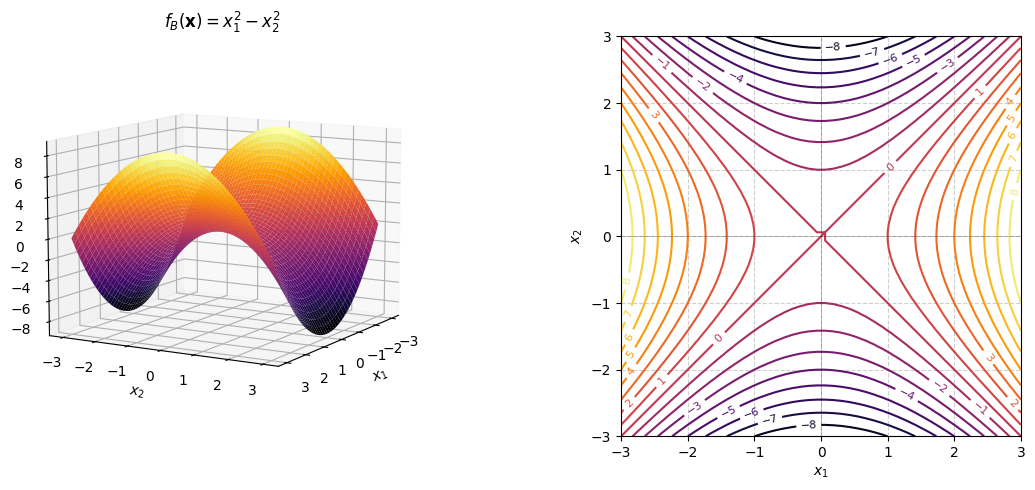

In [9]:
F_b = X1**2 - X2**2

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1, X2, F_b, cmap='inferno', edgecolor='none')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f_B$')
ax1.set_title(r'$f_B(\mathbf{x})=x_1^2-x_2^2$')
ax1.view_init(elev=10, azim=30)

ax2 = fig.add_subplot(1, 2, 2)
contours = ax2.contour(X1, X2, F_b, levels=20, cmap='inferno')
ax2.clabel(contours, inline=True, fontsize=8)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.6)
#ax2.scatter(0, 0, color='orange', marker='x', s=40)
ax2.set_aspect('equal', 'box')  

plt.tight_layout()
plt.show()

If we compute de gradient of $f_B$ and set it equal to zero, we get:

$\nabla f_B (\mathbf{x}) = \left(2x_1, -2x_2\right)^T=\textbf{0}\ \ \textrm{when} \ \ \mathbf{x^*}=(0,0)^T.$

So, again, the same result as before for now. Let's compute its Hessian:

$H_{f_B}:=\nabla^2 f_B(\mathbf{x}) =\begin{bmatrix}
2 & 0 \\[2mm]
0 & -2
\end{bmatrix}$.

Its eigenvalues are:

In [10]:
H_fB = np.array([[2, 0],
              [0, -2]])

eigvals_HfB = np.linalg.eigvals(H_fB)
print(eigvals_HfB)

[ 2. -2.]


We have reached then one of the cases we had only discussed theoretically but not yet encountered in practice: the Hessian has both positive and negative eigenvalues (in this particular case $\lambda_1=2$ and $\lambda_2=-2$). This means that the critical point $(0,0)^T$ is neither a minimum nor a maximum. Instead, it is a $\textbf{saddle point}$, as we can also confirm by taking a look to the function plot shown above: in one direction the surface curves upwards, while in the other it curves downwards.

Looking at the contour plot, we can spot that starting from point $(0,0)$ there is an increasing direction, which is the $(1,0)$ direction, and then, a decreasing direction, in this case $(0,1)$. This is exactly what the eigenvalues' signs are telling us: it is a saddle point. 

To study the remaining case, we now proceed to analyze the function $f_C(\mathbf{x}) = x_1^2$. Let's start by plotting $f_C$:

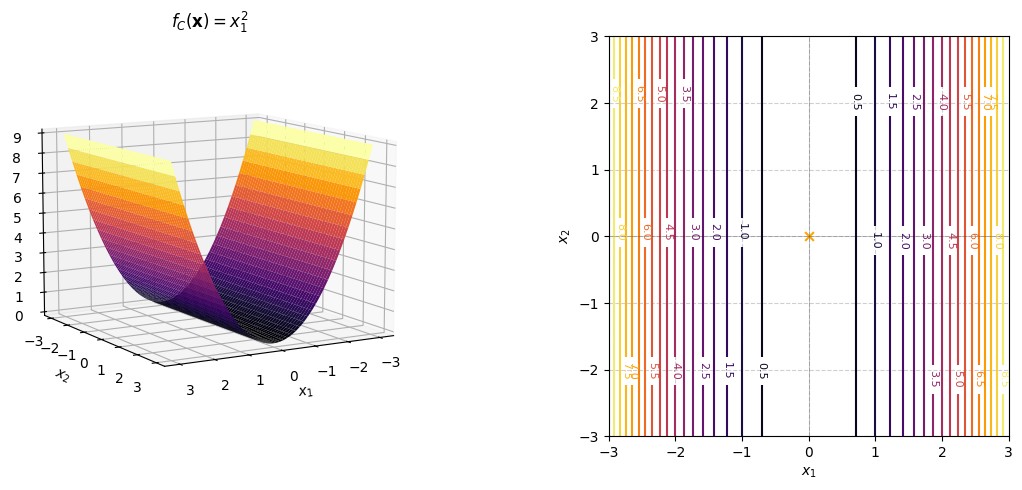

In [11]:
F_c = X1**2

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1, X2, F_c, cmap='inferno', edgecolor='none')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f_C$')
ax1.set_title(r'$f_C(\mathbf{x})=x_1^2$')
ax1.view_init(elev=10, azim=60)

ax2 = fig.add_subplot(1, 2, 2)
contours = ax2.contour(X1, X2, F_c, levels=20, cmap='inferno')
ax2.clabel(contours, inline=True, fontsize=8)
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.scatter(0, 0, color='orange', marker='x', s=40)
ax2.set_aspect('equal', 'box')  

plt.tight_layout()
plt.show()


If we compute de gradient of $f_C$ and set it equal to zero, we get:

$\nabla f_C (\mathbf{x}) = \left(2x_1, 0\right)^T=\textbf{0} \ \ \textrm{when} \ \ \mathbf{x^*}=(0, x_2)^T \mid x_2 \in \mathbb{R}^2$

Thus, the gradient is zero when $x_1=0$, regardless of the value of $x_2$. This means that we have infinitely many critical points along the line defined by $x_1=0$. To study them further, we calculate the Hessian.

$H_{f_C}:=\nabla^2 f_C(\mathbf{x}) =\begin{bmatrix}
2 & 0 \\[2mm]
0 & 0
\end{bmatrix}$.

In [12]:
H_fC = np.array([[2, 0],
              [0, 0]])

eigvals_HfC = np.linalg.eigvals(H_fC)
print(eigvals_HfC)

[2. 0.]


The eigenvalues of the Hessian matrix of $f_C$ are $\lambda_1=2$ and $\lambda_2=0$. Hence, $H_{f_C}$ is positive semidefinite (PSD). This indicates that the function is convex along the $x_1$-direction and flat along the $x_2$. Therefore, **``there is no strict local minima``** but a contour line of minima. 

### 2.2 A two-dimensional function with multiple minima
The function we study is:
$$\boxed{f(x_1,x_2) = x_1^2(4 - 2.1x_1^2 + \frac{1}{3}x_1^4) + x_1x_2 + x_2^2(-4 + 4x_2^2)}$$

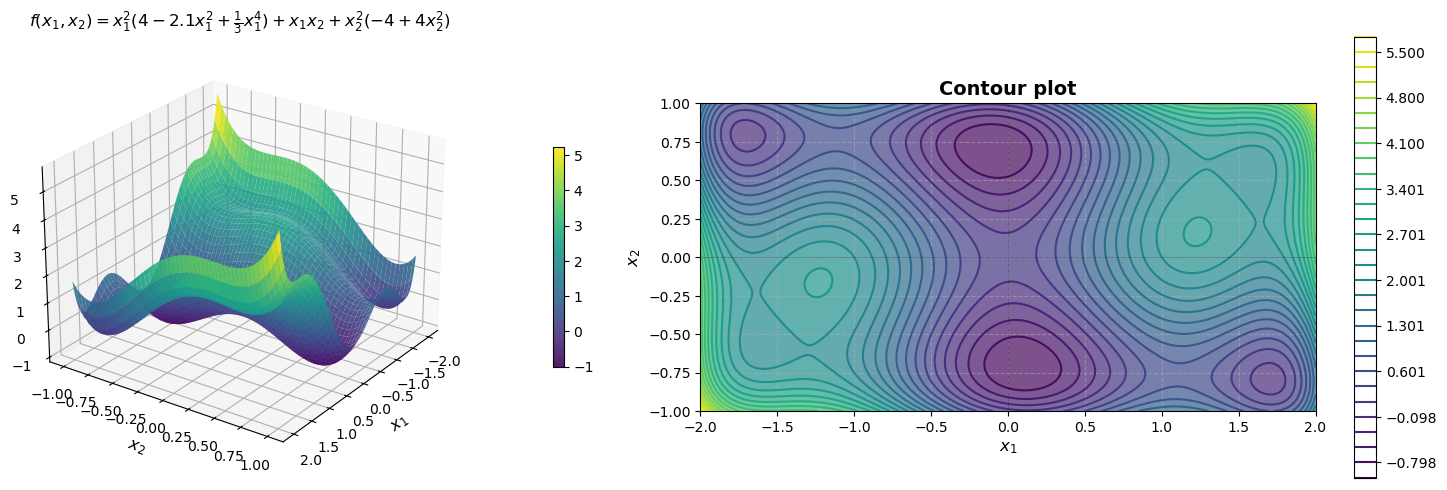

In [3]:
def f(x1, x2):
    return (x1**2 * (4 - 2.1*x1**2 + (1/3)*x1**4) +
            x1*x2 +
            x2**2 * (-4 + 4*x2**2))


x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-1, 1, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel(r'$x_1$', fontsize=12)
ax1.set_ylabel(r'$x_2$', fontsize=12)
ax1.set_zlabel(r'$f(x_1,x_2)$', fontsize=12)
ax1.set_title(r'$f(x_1,x_2) = x_1^2(4 - 2.1x_1^2 + \frac{1}{3}x_1^4) + x_1x_2 + x_2^2(-4 + 4x_2^2)$',
              fontsize=12, fontweight='bold')
ax1.view_init(elev=25, azim=35)
fig.colorbar(surf, ax=ax1, shrink=0.5, pad=0.12)

ax2 = fig.add_subplot(122)
levels = np.linspace(Z.min(), Z.max(), 30)
contour = ax2.contour(X1, X2, Z, levels=levels, cmap='viridis')
ax2.contourf(X1, X2, Z, levels=levels, cmap='viridis', alpha=0.7)
ax2.set_xlabel(r'$x_1$', fontsize=12)
ax2.set_ylabel(r'$x_2$', fontsize=12)
ax2.set_title('Contour plot', fontsize=14, fontweight='bold')
ax2.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax2.axis('equal')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_aspect('equal', 'box')
fig.colorbar(contour, ax=ax2, pad=0.05)

plt.tight_layout()
plt.show()

We can observe that, within the plotted grid, there are several local maxima and minima, as well as saddle points, which we can already approximately locate with the help of the contour plot.

Let us compute the **partial derivatives** in order to obtain the gradient:

$$
\nabla f(x_1,x_2) =
\begin{pmatrix}
\dfrac{\partial f}{\partial x_1} \\[4pt]
\dfrac{\partial f}{\partial x_2}
\end{pmatrix}.
$$

Hence,

$$
\begin{aligned}
\dfrac{\partial f}{\partial x_1}
&= 2x_1\left(4 - 2.1x_1^2 + \frac{1}{3}x_1^4\right)
   + x_1^2\left(-4.2x_1 + \frac{4}{3}x_1^3\right) + x_2, \\[4pt]
\dfrac{\partial f}{\partial x_2}
&= x_1 + 2x_2\left(-4 + 4x_2^2\right) + x_2^2(8x_2).
\end{aligned}
$$

We want to find points such that $(x_1,x_2)\in[-2,2]\times[-1,1]$ such that $||{\nabla f(x_1,x_2)}|| \approx 0$. We create a grid:

In [4]:
def gradient_f(x1, x2):
    df_dx1 = 2*x1*(4 - 2.1*x1**2 + (1/3)*x1**4) + x1**2*(-4.2*x1 + (4/3)*x1**3) + x2
    df_dx2 = x1 + 2*x2*(-4 + 4*x2**2) + 8*x2**3
    return np.array([df_dx1, df_dx2])


step = 0.005
x1_grid = np.arange(-2, 2 + step, step)
x2_grid = np.arange(-1, 1 + step, step)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

# Compute the squared norm of the gradient on the whole grid
grad_norm_sq = np.zeros_like(X1_grid)
for i in range(X1_grid.shape[0]):
    for j in range(X1_grid.shape[1]):
        grad = gradient_f(X1_grid[i, j], X2_grid[i, j])
        grad_norm_sq[i, j] = np.linalg.norm(grad) ** 2

# Restrict attention to interior points only
interior_grad_norm_sq = grad_norm_sq[1:-1, 1:-1]
print("Grid information:")
print(f"  Interior points: {interior_grad_norm_sq.shape[0]} × {interior_grad_norm_sq.shape[1]}")
print(f"  Minimum ||∇f||² in the interior: {interior_grad_norm_sq.min():.6e}")

# 8-neighborhood for a local minimum check
neighbors = [(-1, -1), (-1, 0), (-1, 1),
             (0, -1),           (0, 1),
             (1, -1),  (1, 0),  (1, 1)]

candidates = []
for i in range(1, X1_grid.shape[0] - 1):
    for j in range(1, X1_grid.shape[1] - 1):
        current_value = grad_norm_sq[i, j]
        is_local_min = True

        for di, dj in neighbors:
            if grad_norm_sq[i + di, j + dj] <= current_value:
                is_local_min = False
                break

        if is_local_min:
            candidates.append((X1_grid[i, j], X2_grid[i, j], current_value))

candidates.sort(key=lambda x: x[2])

print("\nCandidate critical points:")
print("-" * 84)
print(f"{'#':>3} {'x₁':>12} {'x₂':>12} {'||∇f(x)||²':>16} {'f(x)':>14}")
print("-" * 84)

for idx, (x1_c, x2_c, grad_norm) in enumerate(candidates[:20], 1):
    f_value = f(x1_c, x2_c)
    print(f"{idx:>3} {x1_c:>12.6f} {x2_c:>12.6f} {grad_norm:>16.6e} {f_value:>14.6f}")

print("-" * 84)

Grid information:
  Interior points: 399 × 799
  Minimum ||∇f||² in the interior: 1.181911e-25

Candidate critical points:
------------------------------------------------------------------------------------
  #           x₁           x₂       ||∇f(x)||²           f(x)
------------------------------------------------------------------------------------
  1    -0.000000     0.000000     1.181911e-25       0.000000
  2    -1.295000    -0.605000     4.540504e-05       2.229467
  3     1.295000     0.605000     4.540504e-05       2.229467
  4     1.230000     0.160000     2.418181e-04       2.496277
  5    -1.230000    -0.160000     2.418181e-04       2.496277
  6    -1.605000    -0.570000     4.156535e-04       2.104276
  7     1.605000     0.570000     4.156535e-04       2.104276
  8     1.640000     0.230000     6.745825e-04       2.229378
  9    -1.640000    -0.230000     6.745825e-04       2.229378
 10     1.110000    -0.770000     1.255928e-03       0.543745
 11    -1.110000     0.77

In order to determine whether our candidates are minima or maxima, we compute their respective Hessian matrices. For that, let us calculate the **second-order derivatives**. For the mixed partial derivatives, one can easily see that

$$
\frac{\partial^2 f}{\partial x_1\partial x_2}
= \frac{\partial^2 f}{\partial x_2\partial x_1} = 1.
$$

Also,

$$
\frac{\partial^2 f}{\partial x_1^2}
= 2\left(4 - 2.1x_1^2 + \frac{1}{3}x_1^4\right)
+ 2x_1\left(-4.2x_1 + \frac{4}{3}x_1^3\right)
+ x_1^2\left(-4.2 + 4x_1^2\right),
$$

and

$$
\frac{\partial^2 f}{\partial x_2^2} = -8 + 48x_2^2.
$$

Therefore, the Hessian matrix at a point $(x_1,x_2)$ is

$$
H_f(x_1,x_2)
=
\begin{pmatrix}
\dfrac{\partial^2 f}{\partial x_1^2} & \dfrac{\partial^2 f}{\partial x_1\partial x_2} \\[8pt]
\dfrac{\partial^2 f}{\partial x_2\partial x_1} & \dfrac{\partial^2 f}{\partial x_2^2}
\end{pmatrix}
=
\begin{pmatrix}
2\left(4 - 2.1x_1^2 + \frac{1}{3}x_1^4\right)
+ 2x_1\left(-4.2x_1 + \frac{4}{3}x_1^3\right)
+ x_1^2\left(-4.2 + 4x_1^2\right) & 1 \\[10pt]
1 & -8 + 48x_2^2
\end{pmatrix}.
$$

Now we are going to study how all Hessian matrices behave as quadratic forms, that is, we are going to determine the sign of

$$
\mathbf{z}^T H_f(\mathbf{x})\mathbf{z}, \qquad \forall \mathbf{z}\in\mathbb{R}^2.
$$

- If $\mathbf{z}^T H_f(\mathbf{x})\mathbf{z} > 0$ for all $\mathbf{z}\in\mathbb{R}^2$, then $\mathbf{x}$ is a local minimum.
- If $\mathbf{z}^T H_f(\mathbf{x})\mathbf{z} < 0$ for all $\mathbf{z}\in\mathbb{R}^2$, then $\mathbf{x}$ is a local maximum.
- If $\mathbf{z}^T H_f(\mathbf{x})\mathbf{z} > 0$ for some $\mathbf{z}$ and $\mathbf{w}^T H_f(\mathbf{x})\mathbf{w} < 0$ for some $\mathbf{w}$, then $\mathbf{x}$ is a saddle point.\\

This is equivalent to studyng the signs of the Hessian eigenvalues.

In [5]:
print("=" * 72)
print("STEP 4: Hessian matrix analysis")
print("=" * 72)


def hessian_f(x1, x2):
    d2f_dx1_2 = 2*(4 - 2.1*x1**2 + (1/3)*x1**4) + 2*x1*(-4.2*x1 + (4/3)*x1**3) + x1**2*(-4.2 + 4*x1**2)
    d2f_dx1_dx2 = 1
    d2f_dx2_2 = -8 + 48*x2**2

    H = np.array([[d2f_dx1_2, d2f_dx1_dx2],
                  [d2f_dx1_dx2, d2f_dx2_2]])
    return H


for idx, (x1_c, x2_c, grad_norm) in enumerate(candidates[:15], 1):
    H = hessian_f(x1_c, x2_c)
    eigenvalues = np.linalg.eigvals(H)
    eigenvalues_sorted = np.sort(eigenvalues)[::-1]
    f_value = f(x1_c, x2_c)

    print("\n" + "─" * 80)
    print(f"Critical point #{idx}: ({x1_c:.6f}, {x2_c:.6f})")
    print("─" * 80)
    print(f"  f(x) = {f_value:.8f}")
    print(f"  ||∇f(x)||² = {grad_norm:.6e}")
    print("\n  Hessian matrix H:")
    print(np.array2string(H, precision=6, separator=', '))
    print(f"\n  Eigenvalues: λ₁ = {eigenvalues_sorted[0]:.6f}, λ₂ = {eigenvalues_sorted[1]:.6f}")

print("\n" + "=" * 72)

STEP 4: Hessian matrix analysis

────────────────────────────────────────────────────────────────────────────────
Critical point #1: (-0.000000, 0.000000)
────────────────────────────────────────────────────────────────────────────────
  f(x) = 0.00000000
  ||∇f(x)||² = 1.181911e-25

  Hessian matrix H:
[[ 8.,  1.],
 [ 1., -8.]]

  Eigenvalues: λ₁ = 8.062258, λ₂ = -8.062258

────────────────────────────────────────────────────────────────────────────────
Critical point #2: (-1.295000, -0.605000)
────────────────────────────────────────────────────────────────────────────────
  f(x) = 2.22946744
  ||∇f(x)||² = 4.540504e-05

  Hessian matrix H:
[[0.450341, 1.      ],
 [1.      , 9.5692  ]]

  Eigenvalues: λ₁ = 9.677575, λ₂ = 0.341966

────────────────────────────────────────────────────────────────────────────────
Critical point #3: (1.295000, 0.605000)
────────────────────────────────────────────────────────────────────────────────
  f(x) = 2.22946744
  ||∇f(x)||² = 4.540504e-05

  Hess

Then, by knowing the sign of both eigenvalues of H at each point, we can classify them as local minima, local maxima or saddle points.

### Final classification table

| Point | λ₁ | λ₂ | Type |
|---|---:|---:|---|
| $(0.000, 0.000)$ | 8.062 | -8.062 | Saddle |
| $(-1.295, -0.605)$ | 9.678 | 0.342 | Local min |
| $(1.295, 0.605)$ | 9.678 | 0.342 | Local min |
| $(1.230, 0.160)$ | -0.473 | -6.930 | Local max |
| $(-1.230,-0.160)$ | -0.473 | -6.930 | Local max |
| $(-1.605,-0.570)$ | 13.554 | 7.427 | Local min |
| $(1.605, 0.570)$ | 13.554 | 7.427 | Local min |
| $(1.640, 0.230)$ | 15.910 | -5.508 | Saddle |
| $(-1.640,-0.230)$ | 15.910 | -5.508 | Saddle |
| $(1.110,-0.770)$ | 20.505 | -1.612 | Saddle |
| $(-1.110, 0.770)$ | 20.505 | -1.612 | Saddle |
| $(1.705,-0.795)$ | 22.903 | 20.569 | Local min |
| $(-1.705, 0.795)$ | 22.903 | 20.569 | Local min |
| $(-0.090, 0.715)$ | 16.653 | 7.751 | Local min |
| $(0.090,-0.715)$ | 16.653 | 7.751 | Local min |

We can visualize all the critical points:

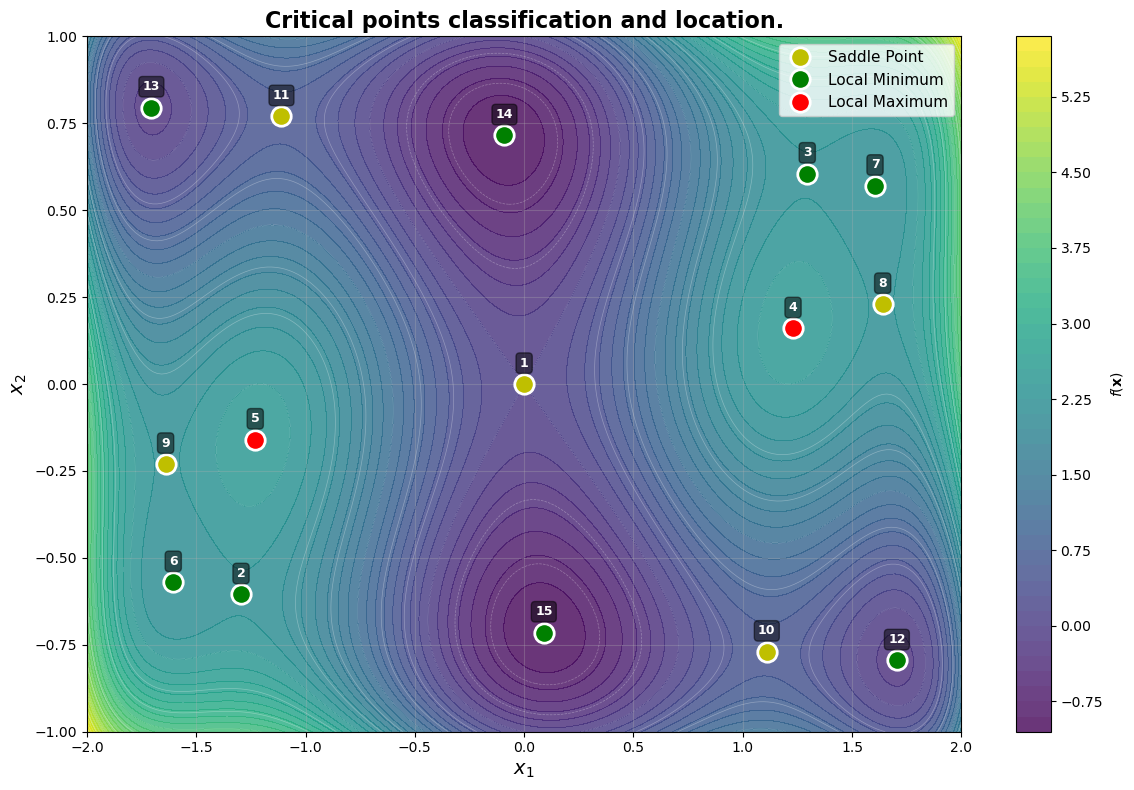

In [7]:
results = [
    {"index": 1, "x1": 0.000,  "x2": 0.000,  "l1":  8.062, "l2": -8.062, "type": "saddle"},
    {"index": 2, "x1": -1.295, "x2": -0.605, "l1":  9.678, "l2":  0.342, "type": "min"},
    {"index": 3, "x1":  1.295, "x2":  0.605, "l1":  9.678, "l2":  0.342, "type": "min"},
    {"index": 4, "x1":  1.230, "x2":  0.160, "l1": -0.473, "l2": -6.930, "type": "max"},
    {"index": 5, "x1": -1.230, "x2": -0.160, "l1": -0.473, "l2": -6.930, "type": "max"},
    {"index": 6, "x1": -1.605, "x2": -0.570, "l1": 13.554, "l2":  7.427, "type": "min"},
    {"index": 7, "x1":  1.605, "x2":  0.570, "l1": 13.554, "l2":  7.427, "type": "min"},
    {"index": 8, "x1":  1.640, "x2":  0.230, "l1": 15.910, "l2": -5.508, "type": "saddle"},
    {"index": 9, "x1": -1.640, "x2": -0.230, "l1": 15.910, "l2": -5.508, "type": "saddle"},
    {"index": 10, "x1":  1.110, "x2": -0.770, "l1": 20.505, "l2": -1.612, "type": "saddle"},
    {"index": 11, "x1": -1.110, "x2":  0.770, "l1": 20.505, "l2": -1.612, "type": "saddle"},
    {"index": 12, "x1":  1.705, "x2": -0.795, "l1": 22.903, "l2": 20.569, "type": "min"},
    {"index": 13, "x1": -1.705, "x2":  0.795, "l1": 22.903, "l2": 20.569, "type": "min"},
    {"index": 14, "x1": -0.090, "x2":  0.715, "l1": 16.653, "l2":  7.751, "type": "min"},
    {"index": 15, "x1":  0.090, "x2": -0.715, "l1": 16.653, "l2":  7.751, "type": "min"},
]

fig, ax = plt.subplots(figsize=(12, 8))

contourf = ax.contourf(X1, X2, Z, levels=50, cmap=cm.viridis, alpha=0.8)
contour = ax.contour(X1, X2, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

for r in results:
    if r["type"] == "min":
        ax.plot(
            r["x1"], r["x2"],
            "go",
            markersize=14,
            markeredgecolor="white",
            markeredgewidth=2,
            label="Local Minimum" if r["index"] == 2 else "",
        )
    elif r["type"] == "max":
        ax.plot(
            r["x1"], r["x2"],
            "ro",
            markersize=14,
            markeredgecolor="white",
            markeredgewidth=2,
            label="Local Maximum" if r["index"] == 4 else "",
        )
    elif r["type"] == "saddle":
        ax.plot(
            r["x1"], r["x2"],
            "yo",
            markersize=14,
            markeredgecolor="white",
            markeredgewidth=2,
            label="Saddle Point" if r["index"] == 1 else "",
        )

    ax.text(
        r["x1"], r["x2"] + 0.05,
        str(r["index"]),
        color="white",
        fontsize=9,
        ha="center",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.5),
    )

ax.set_xlabel(r'$x_1$', fontsize=14)
ax.set_ylabel(r'$x_2$', fontsize=14)
ax.set_title("Critical points classification and location.", fontsize=16, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.colorbar(contourf, ax=ax, label=r'$f(\mathbf{x})$')

plt.tight_layout()
plt.show()